## Dependencies

In [1]:
import numpy as np
import nibabel as nib
import torch.nn.functional as F
import glob
import matplotlib.pyplot as plt
from tifffile import imwrite
from sklearn.preprocessing import MinMaxScaler
import torch
from pathlib import Path
import os
import splitfolders
import shutil
from torch.utils.data import Dataset,DataLoader

scaler=MinMaxScaler()
TRAIN_DATASET_PATH = Path('../data/brats20/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/')
VALIDATION_DATASET_PATH = Path('../data/brats20/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData')
file_number = np.random.randint(100,369)

## EDA

1854.603271484375
[0 1 2 4]
[0 1 2 3]
(240, 240, 155)
Slice number: 117


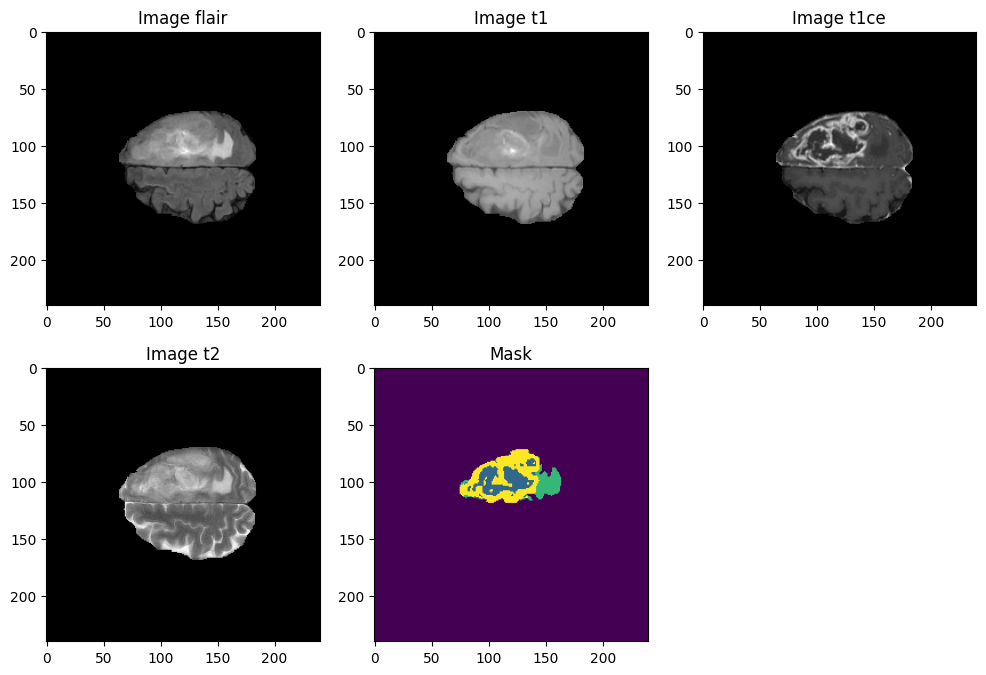

(240, 240, 155)


In [2]:
test_image_flair=nib.load(next(TRAIN_DATASET_PATH.rglob('*355_flair.nii'))).get_fdata()
print(test_image_flair.max())
#Scalers are applied to 1D so let us reshape and then reshape back to original shape. 
test_image_flair=scaler.fit_transform(test_image_flair.reshape(-1, test_image_flair.shape[-1])).reshape(test_image_flair.shape)


test_image_t1=nib.load(next(TRAIN_DATASET_PATH.rglob('*355_t1.nii'))).get_fdata()
test_image_t1=scaler.fit_transform(test_image_t1.reshape(-1, test_image_t1.shape[-1])).reshape(test_image_t1.shape)

test_image_t1ce=nib.load(next(TRAIN_DATASET_PATH.rglob('*355_t1ce.nii'))).get_fdata()
test_image_t1ce=scaler.fit_transform(test_image_t1ce.reshape(-1, test_image_t1ce.shape[-1])).reshape(test_image_t1ce.shape)

test_image_t2=nib.load(next(TRAIN_DATASET_PATH.rglob('*355_t2.nii'))).get_fdata()
test_image_t2=scaler.fit_transform(test_image_t2.reshape(-1, test_image_t2.shape[-1])).reshape(test_image_t2.shape)

test_mask=nib.load(next(TRAIN_DATASET_PATH.rglob('*355_seg.nii'))).get_fdata()
test_mask=test_mask.astype(np.uint8)

print(np.unique(test_mask))  #0, 1, 2, 4 (Need to reencode to 0, 1, 2, 3)
test_mask[test_mask==4] = 3  #Reassign mask values 4 to 3
print(np.unique(test_mask)) 

print(test_image_flair.shape)

import random
n_slice=random.randint(0, test_mask.shape[2]-1)
print('Slice number:',n_slice)

plt.figure(figsize=(12, 8))

plt.subplot(231)
plt.imshow(test_image_flair[:,:,n_slice], cmap='gray')
plt.title('Image flair')
plt.subplot(232)
plt.imshow(test_image_t1[:,:,n_slice], cmap='gray')
plt.title('Image t1')
plt.subplot(233)
plt.imshow(test_image_t1ce[:,:,n_slice], cmap='gray')
plt.title('Image t1ce')
plt.subplot(234)
plt.imshow(test_image_t2[:,:,n_slice], cmap='gray')
plt.title('Image t2')
plt.subplot(235)
plt.imshow(test_mask[:,:,n_slice])
plt.title('Mask')
plt.show()

print(test_mask.shape)

Original shape of input: (240, 240, 155, 3)
FInal shape of input: (128, 128, 128, 3)
Final shape of mask: (128, 128, 128)
Slice number: 35


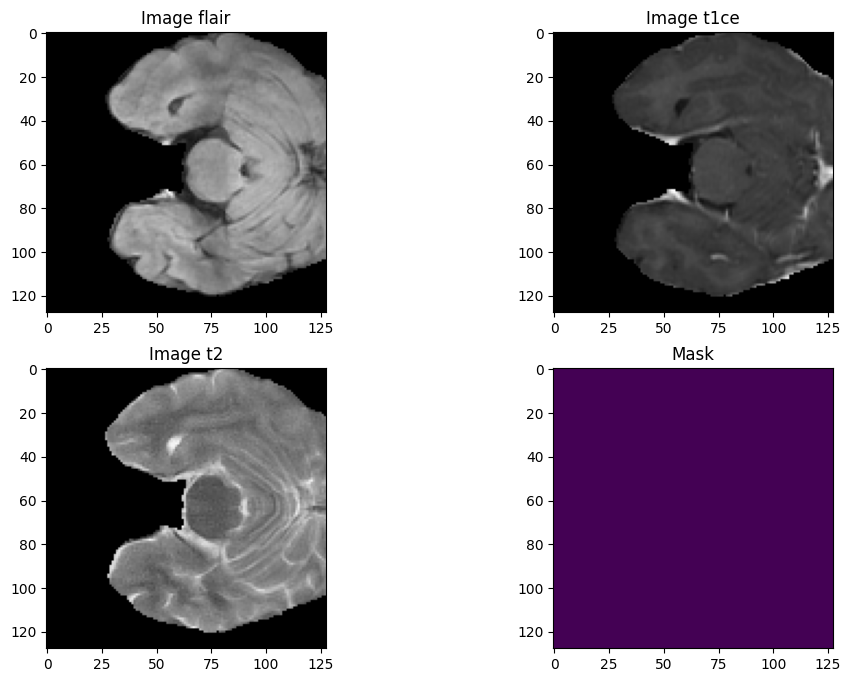

Encoded mask: torch.Size([128, 128, 128, 4])


In [3]:
combined_x = np.stack([test_image_flair, test_image_t1ce, test_image_t2], axis=3)
print("Original shape of input:",combined_x.shape)

#Crop to a size to be divisible by 64 so we can later extract 64x64x64 patches. 
#cropping x, y, and z
#combined_x=combined_x[24:216, 24:216, 13:141] [48:192,48:192,13:141]

combined_x=combined_x[56:184, 56:184, 13:141] #Crop to 128x128x128x4
print("FInal shape of input:",combined_x.shape)

#Do the same for mask
test_mask_2 = test_mask[56:184, 56:184, 13:141]

print("Final shape of mask:",test_mask_2.shape)


n_slice=random.randint(0, test_mask_2.shape[2]-1)
print("Slice number:",n_slice)
plt.figure(figsize=(12, 8))

plt.subplot(221)
plt.imshow(combined_x[:,:,n_slice, 0], cmap='gray')
plt.title('Image flair')
plt.subplot(222)
plt.imshow(combined_x[:,:,n_slice, 1], cmap='gray')
plt.title('Image t1ce')
plt.subplot(223)
plt.imshow(combined_x[:,:,n_slice, 2], cmap='gray')
plt.title('Image t2')
plt.subplot(224)
plt.imshow(test_mask_2[:,:,n_slice])
plt.title('Mask')
plt.show()

test_mask_2 = F.one_hot(torch.tensor(test_mask_2).long(), num_classes=4)
print("Encoded mask:",test_mask_2.shape)

# Data Pipeline

## Data Transform 1

### Helper function

In [4]:
def transform_nii_to_tensor(t2_list: list, t1ce_list: list, flair_list: list, mask_list: list,
                               save_images: str, save_masks: str,scaler):

    os.makedirs(save_images, exist_ok=True)
    os.makedirs(save_masks, exist_ok=True)
    saved_samples = []
    discarded_samples = []

    for img in range(len(t2_list)):
        # Load and normalize
        img_t2 = nib.load(t2_list[img]).get_fdata()
        img_t2 = scaler.fit_transform(img_t2.reshape(-1, img_t2.shape[-1])).reshape(img_t2.shape)

        img_t1ce = nib.load(t1ce_list[img]).get_fdata()
        img_t1ce = scaler.fit_transform(img_t1ce.reshape(-1, img_t1ce.shape[-1])).reshape(img_t1ce.shape)

        img_flair = nib.load(flair_list[img]).get_fdata()
        img_flair = scaler.fit_transform(img_flair.reshape(-1, img_flair.shape[-1])).reshape(img_flair.shape)

        # Stack channels and crop
        stacked_img = np.stack([img_flair, img_t1ce, img_t2], axis=3)  # [D, H, W, C]
        stacked_img = stacked_img[56:184, 56:184, 13:141]              # [128, 128, 128, 3]
        stacked_img = torch.from_numpy(stacked_img).permute(3, 0, 1, 2).float()  # [C, D, H, W]

        # Load and process mask
        img_mask = nib.load(mask_list[img]).get_fdata().astype(np.uint8)
        img_mask[img_mask == 4] = 3
        img_mask = img_mask[56:184, 56:184, 13:141]  # [128, 128, 128]
        img_mask = torch.from_numpy(img_mask).long()

        # Check tumor content threshold
        val, counts = np.unique(img_mask.numpy(), return_counts=True)
        if (1 - (counts[0] / counts.sum())) > 0.01:
            saved_samples.append(img)
            torch.save(stacked_img, os.path.join(save_images, f"image_{img}.pt"))
            torch.save(img_mask, os.path.join(save_masks, f"mask_{img}.pt"))
        else:
            discarded_samples.append(img)

    return saved_samples, discarded_samples

In [5]:
# def transform_nii_to_tensor(t2_list:list,t1ce_list:list,flair_list:list,mask_list:list,save_images:str,save_masks:str):

#     os.makedirs(save_images,exist_ok=True)
#     os.makedirs(save_masks,exist_ok=True)
#     saved_samples = []
#     discarded_samples = []
    
#     for img in range(len(t2_list)):
#         img_t2 = nib.load(filename=t2_list[img]).get_fdata()
#         img_t2 = scaler.fit_transform(img_t2.reshape(-1,img_t2.shape[-1])).reshape(img_t2.shape)

#         img_t1ce = nib.load(filename=t1ce_list[img]).get_fdata()
#         img_t1ce = scaler.fit_transform(img_t1ce.reshape(-1,img_t1ce.shape[-1])).reshape(img_t1ce.shape)

#         img_flair = nib.load(filename=flair_list[img]).get_fdata()
#         img_flair = scaler.fit_transform(img_flair.reshape(-1,img_flair.shape[-1])).reshape(img_flair.shape)

#         stacked_img = np.stack([img_flair,img_t1ce,img_t2],axis=3)
#         stacked_img = stacked_img[56:184, 56:184, 13:141]

#         img_mask = nib.load(filename=mask_list[img]).get_fdata().astype(np.uint8)
#         img_mask[img_mask==4]=3
#         img_mask = img_mask[56:184, 56:184, 13:141]

#         val,counts = np.unique(img_mask,return_counts=True)

#         if (1-(counts[0]/counts.sum())) > 0.01:
#             saved_samples.append(img)
#             img_mask_np = F.one_hot(torch.tensor(img_mask).long(),num_classes=4).numpy()
#             np.save(file=f"../data/brats20/train_data_3channel/images/image_{img}.npy",arr=stacked_img)
#             np.save(file=f"../data/brats20/train_data_3channel/masks/mask_{img}.npy",arr=img_mask_np)
#         else:
#             discarded_samples.append(img)

#     return saved_samples,discarded_samples

### Training data

In [ ]:
# t2_list = sorted(TRAIN_DATASET_PATH.rglob(pattern='*t2.nii'))
# t1ce_list = sorted(TRAIN_DATASET_PATH.rglob(pattern='*t1ce.nii'))
# flair_list = sorted(TRAIN_DATASET_PATH.rglob(pattern='*flair.nii'))
# mask_list = sorted(TRAIN_DATASET_PATH.rglob(pattern='*seg.nii'))
# save_images = "../data/brats20/train_data_3channel/images/"
# save_masks = "../data/brats20/train_data_3channel/masks/"

# saved,discarded = transform_nii_to_tensor(t1ce_list=t1ce_list,
#                     t2_list=t2_list,
#                     flair_list=flair_list,
#                     mask_list=mask_list,
#                     save_images=save_images,
#                     save_masks=save_masks,scaler=scaler)

# print(f'Saved files: {len(saved)}\n\n {saved}\n\nDiscarded files: {len(discarded)} \n\n {discarded}')

Saved files: 344

 [0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 28, 29, 30, 31, 32, 33, 34, 36, 37, 38, 39, 40, 41, 42, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 61, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 79, 80, 82, 83, 84, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 99, 100, 101, 102, 103, 104, 105, 106, 108, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 139, 140, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 233, 234,

In [ ]:
# io_folder = "../data/brats20/train_data_3channel/"
# splitfolders.ratio(input=io_folder,output = io_folder, seed = 42, ratio=(.75,.25),group_prefix = None)
# shutil.rmtree(save_images)
# shutil.rmtree(save_masks)

Copying files: 688 files [00:18, 36.69 files/s]


### Test data

In [8]:
# t2_list = sorted(VALIDATION_DATASET_PATH.rglob(pattern='*t2.nii'))
# t1ce_list = sorted(VALIDATION_DATASET_PATH.rglob(pattern='*t1ce.nii'))
# flair_list = sorted(VALIDATION_DATASET_PATH.rglob(pattern='*flair.nii'))
# mask_list = sorted(VALIDATION_DATASET_PATH.rglob(pattern='*seg.nii'))
# save_images = "../data/brats20/test_data_3channel/images/"
# save_masks = "../data/brats20/test_data_3channel/masks/"

# saved,discarded = transform_nii_to_np(t1ce_list=t1ce_list,
#                     t2_list=t2_list,
#                     flair_list=flair_list,
#                     mask_list=mask_list,
#                     save_images=save_images,
#                     save_masks=save_masks)

# print(f'Saved files: {len(saved)}\n\n {saved}\n\nDiscarded files: {len(discarded)} \n\n {discarded}')

In [9]:
# io_folder = "../data/brats20/test_data_3channel/"
# shutil.rmtree(save_images)
# shutil.rmtree(save_masks)

## Creating Data loaders

In [10]:
class BraTsDataset(Dataset):
    def __init__(self, img_dir:str, img_list:list, mask_dir:str, mask_list:list):
        self.img_dir = img_dir
        self.img_list = img_list
        self.mask_dir = mask_dir
        self.mask_list = mask_list

    def __len__(self):
        return len(self.img_list)

    def __getitem__(self, idx):
        img = torch.load(self.img_dir + self.img_list[idx])
        mask = torch.load(self.mask_dir + self.mask_list[idx])
        return img, mask
    

In [28]:
img_dir = "../data/brats20/train_data_3channel/train/images/"
masks_dir = "../data/brats20/train_data_3channel/train/masks/"
img_list = os.listdir(path=img_dir)
mask_list = os.listdir(path=masks_dir)


train_data = BraTsDataset(img_dir=img_dir,
                          img_list=img_list,
                          mask_dir=masks_dir,
                          mask_list=mask_list)
train_loader = DataLoader(train_data,batch_size=8,shuffle=True)

In [29]:
for img,mask in train_loader:
    print(img.shape,mask.shape)
    break

torch.Size([8, 3, 128, 128, 128]) torch.Size([8, 128, 128, 128])


In [24]:
# # Assume: img, msk are torch tensors from a DataLoader
# img, msk = next(iter(train_loader))  # one batch

# img_num = np.random.randint(0, img.shape[0] - 1)
# test_img = img[img_num].detach().cpu().numpy()
# test_mask = msk[img_num].detach().cpu().numpy()

# # If your mask has one-hot encoding or channel dim
# if test_mask.ndim == 4:  # (C, H, W, D) or (B, C, H, W)
#     test_mask = np.argmax(test_mask, axis=3)

# n_slice = np.random.randint(0, test_mask.shape[2])
# print('Slice number:',n_slice)
# plt.figure(figsize=(12, 8))

# plt.subplot(221)
# plt.imshow(test_img[:, :, n_slice, 0], cmap='gray')
# plt.title('Image flair')

# plt.subplot(222)
# plt.imshow(test_img[:, :, n_slice, 1], cmap='gray')
# plt.title('Image t1ce')

# plt.subplot(223)
# plt.imshow(test_img[:, :, n_slice, 2], cmap='gray')
# plt.title('Image t2')

# plt.subplot(224)
# plt.imshow(test_mask[:, :, n_slice])
# plt.title('Mask')

# plt.tight_layout()
# plt.show()


Slice number: 101


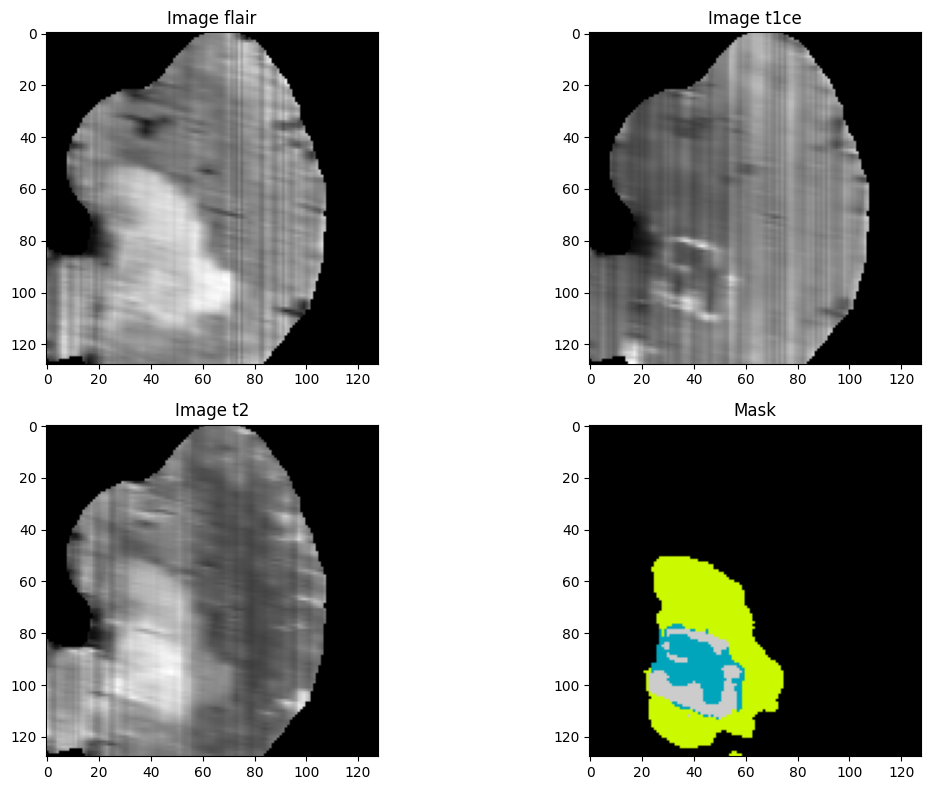

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Load one batch
img, msk = next(iter(train_loader))  # shapes: [B, C, D, H, W], [B, D, H, W]

# Choose a random sample from the batch
img_num = np.random.randint(0, img.shape[0])
test_img = img[img_num].detach().cpu().numpy()  # shape: [3, D, H, W]
test_mask = msk[img_num].detach().cpu().numpy()  # shape: [D, H, W]

# Choose a random slice from the depth (D) dimension
n_slice = np.random.randint(0, test_img.shape[1])
print('Slice number:', n_slice)

plt.figure(figsize=(12, 8))

plt.subplot(221)
plt.imshow(test_img[0, n_slice, :, :], cmap='gray')  # flair
plt.title('Image flair')

plt.subplot(222)
plt.imshow(test_img[1, n_slice, :, :], cmap='gray')  # t1ce
plt.title('Image t1ce')

plt.subplot(223)
plt.imshow(test_img[2, n_slice, :, :], cmap='gray')  # t2
plt.title('Image t2')

plt.subplot(224)
plt.imshow(test_mask[n_slice, :, :], cmap='nipy_spectral')  # segmentation mask
plt.title('Mask')

plt.tight_layout()
plt.show()


In [23]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import imageio
import os

# Create a folder to save GIF frames
os.makedirs("gif_frames", exist_ok=True)

# Load one batch
img, msk = next(iter(train_loader))  # [B, C, D, H, W], [B, D, H, W]
img_num = np.random.randint(0, img.shape[0])

test_img = img[img_num].detach().cpu().numpy()  # [3, D, H, W]
test_mask = msk[img_num].detach().cpu().numpy()  # [D, H, W]

gif_frames = []

# Loop over all slices along depth axis
for n_slice in range(test_img.shape[1]):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(test_img[0, n_slice, :, :], cmap='gray')  # Flair as base
    ax.imshow(test_mask[n_slice, :, :], cmap='jet', alpha=0.4)  # Mask overlay
    ax.set_title(f"Slice {n_slice}")
    ax.axis('off')

    frame_path = f"gif_frames/frame_{n_slice:03d}.png"
    plt.savefig(frame_path)
    gif_frames.append(imageio.imread(frame_path))
    plt.close()

# Save GIF
gif_path = "sample_volume.gif"
imageio.mimsave(gif_path, gif_frames, duration=0.1)  # 0.1s per frame

print(f"GIF saved to {gif_path}")
import matplotlib.pyplot as plt
import numpy as np
import torch
import imageio
import os

# Create a folder to save GIF frames
os.makedirs("gif_frames", exist_ok=True)

# Load one batch
img, msk = next(iter(train_loader))  # [B, C, D, H, W], [B, D, H, W]
img_num = np.random.randint(0, img.shape[0])

test_img = img[img_num].detach().cpu().numpy()  # [3, D, H, W]
test_mask = msk[img_num].detach().cpu().numpy()  # [D, H, W]

gif_frames = []

# Loop over all slices along depth axis
for n_slice in range(test_img.shape[1]):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(test_img[0, n_slice, :, :], cmap='gray')  # Flair as base
    ax.imshow(test_mask[n_slice, :, :], cmap='jet', alpha=0.4)  # Mask overlay
    ax.set_title(f"Slice {n_slice}")
    ax.axis('off')

    frame_path = f"gif_frames/frame_{n_slice:03d}.png"
    plt.savefig(frame_path)
    gif_frames.append(imageio.imread(frame_path))
    plt.close()

# Save GIF
gif_path = "sample_volume.gif"
imageio.mimsave(gif_path, gif_frames, duration=0.1)  # 0.1s per frame

print(f"GIF saved to {gif_path}")


C:\Users\harsh\AppData\Local\Temp\ipykernel_8308\3231000098.py:29: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  gif_frames.append(imageio.imread(frame_path))


GIF saved to sample_volume.gif


C:\Users\harsh\AppData\Local\Temp\ipykernel_8308\3231000098.py:65: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  gif_frames.append(imageio.imread(frame_path))


GIF saved to sample_volume.gif
